# PipelineE K=3 results review

This notebook is for **post-hoc review of an already-fitted PipelineE model**.

It does **not retrain the HMM**. It reads the saved outputs using the **actual save layout from the PipelineE full model script**:

**Saved at `OUT_ROOT`**
- `qc_summary.json`
- `subject_metrics.tsv`
- `run_metrics.tsv`
- `dwell_from_A.tsv`
- `topM_seeds.json`

**Saved at `OUT_ROOT / "final"`**
- `refit_results.json`
- `best_seed.json`
- `trans_prob.npy`
- `state_signature_ut_boldcorr.npy`
- `means_pca.npy`
- `covs_pca.npy`

Main goals:
1. Verify that the final K=3 solution passed QC.
2. Check whether one state dominates globally, per subject, and per run.
3. Quantify transition structure and dwell times.
4. Inspect whether the state signatures look strongly distinct or more like variations around one backbone pattern.
5. Produce figures you can reuse or adapt.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# EDIT THIS PATH ONLY
# This should be PipelineE OUT_ROOT from the full model script:
# OUT_ROOT = Path("/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL") / f"PipelineE_final_K{K_FINAL:02d}_{DATA_VARIANT}_{FEATURE_MODE}_minlen{MINLEN}"
# --------------------------------------------------
RESULT_ROOT = Path('/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15')
FINAL_DIR   = RESULT_ROOT / 'final'

OUT_FIG_DIR = RESULT_ROOT / 'review_figures'
OUT_FIG_DIR.mkdir(exist_ok=True, parents=True)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

def require_file(label, *candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    tried = "\n".join(str(Path(p)) for p in candidates)
    raise FileNotFoundError(f"Could not find {label}. Tried:\n{tried}")

print('RESULT_ROOT:', RESULT_ROOT)
print('FINAL_DIR   :', FINAL_DIR)


RESULT_ROOT: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15
FINAL_DIR   : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final


In [2]:
# ------------------------------
# Resolve and load saved PipelineE outputs
# ------------------------------
QC_PATH         = require_file('qc_summary.json', RESULT_ROOT / 'qc_summary.json')
REFIT_PATH      = require_file('refit_results.json', FINAL_DIR / 'refit_results.json', RESULT_ROOT / 'refit_results.json')
SUBJECT_PATH    = require_file('subject_metrics.tsv', RESULT_ROOT / 'subject_metrics.tsv')
RUN_PATH        = require_file('run_metrics.tsv', RESULT_ROOT / 'run_metrics.tsv')
DWELL_PATH      = require_file('dwell_from_A.tsv', RESULT_ROOT / 'dwell_from_A.tsv')
A_PATH          = require_file('trans_prob.npy', FINAL_DIR / 'trans_prob.npy', RESULT_ROOT / 'trans_prob.npy')
SIG_PATH        = require_file('state_signature_ut_boldcorr.npy', FINAL_DIR / 'state_signature_ut_boldcorr.npy', RESULT_ROOT / 'state_signature_ut_boldcorr.npy')
MEANS_PATH      = require_file('means_pca.npy', FINAL_DIR / 'means_pca.npy', RESULT_ROOT / 'means_pca.npy')
COVS_PATH       = require_file('covs_pca.npy', FINAL_DIR / 'covs_pca.npy', RESULT_ROOT / 'covs_pca.npy')

with open(QC_PATH, 'r', encoding='utf-8') as f:
    qc = json.load(f)

with open(REFIT_PATH, 'r', encoding='utf-8') as f:
    refit = json.load(f)

subject_metrics = pd.read_csv(SUBJECT_PATH, sep='\t')
run_metrics     = pd.read_csv(RUN_PATH, sep='\t')
dwell_from_A    = pd.read_csv(DWELL_PATH, sep='\t')
A               = np.load(A_PATH)
state_sig       = np.load(SIG_PATH)
means_pca       = np.load(MEANS_PATH)
covs_pca        = np.load(COVS_PATH)

print('Resolved files:')
print('  qc_summary.json               ->', QC_PATH)
print('  refit_results.json           ->', REFIT_PATH)
print('  subject_metrics.tsv          ->', SUBJECT_PATH)
print('  run_metrics.tsv              ->', RUN_PATH)
print('  dwell_from_A.tsv             ->', DWELL_PATH)
print('  trans_prob.npy               ->', A_PATH)
print('  state_signature_ut_boldcorr  ->', SIG_PATH)
print('  means_pca.npy                ->', MEANS_PATH)
print('  covs_pca.npy                 ->', COVS_PATH)
print()
print('qc_summary keys:', list(qc.keys()))
print('refit candidates:', len(refit))
print('subject_metrics shape:', subject_metrics.shape)
print('run_metrics shape    :', run_metrics.shape)
print('dwell_from_A shape   :', dwell_from_A.shape)
print('A shape              :', A.shape)
print('state_sig shape      :', state_sig.shape)
print('means_pca shape      :', means_pca.shape)
print('covs_pca shape       :', covs_pca.shape)


Resolved files:
  qc_summary.json               -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/qc_summary.json
  refit_results.json           -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/refit_results.json
  subject_metrics.tsv          -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/subject_metrics.tsv
  run_metrics.tsv              -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/run_metrics.tsv
  dwell_from_A.tsv             -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/dwell_from_A.tsv
  trans_prob.npy               -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/Pi

In [3]:
# ------------------------------
# Helpers
# ------------------------------
STATE_COLS = ['FO_s01', 'FO_s02', 'FO_s03']
STATE_NAMES = ['S1', 'S2', 'S3']


def stationary_distribution(A):
    eigvals, eigvecs = np.linalg.eig(A.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    pi = np.real(eigvecs[:, idx])
    pi = pi / pi.sum()
    return pi


def dwell_from_transition_matrix(A, eps=1e-12):
    A = np.asarray(A, dtype=float)
    Akk = np.clip(np.diag(A), 0.0, 1.0 - eps)
    return 1.0 / (1.0 - Akk)


def entropy_of_fo(fo, eps=1e-12):
    fo = np.asarray(fo, dtype=float)
    fo = np.clip(fo, eps, None)
    fo = fo / fo.sum()
    H = -(fo * np.log(fo)).sum()
    neff = np.exp(H)
    return H, neff


def dominant_state_labels(df, cols=STATE_COLS):
    idx = df[cols].to_numpy().argmax(axis=1)
    return pd.Series(idx + 1, index=df.index)


def pairwise_row_corr(X):
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    out = np.eye(n, dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            c = np.corrcoef(X[i], X[j])[0, 1]
            out[i, j] = c
            out[j, i] = c
    return out

## 1) QC and final-seed recap

This section mirrors the logic of your PipelineE summary:
- collapsed run rate
n- state presence rate across runs
- final selected seed after Top-M refit
- free energy, `FO_max`, and `n_eff`

In [4]:
qc_df = pd.DataFrame([qc]).T
qc_df.columns = ['value']
qc_df

,value
n_runs,15
collapsed_run_count,0
collapsed_run_rate,0.0
run_state_presence,"{'state_01_presence_rate': 1.0, 'state_02_pres..."
seed_identifiability_median_mean_state_corr,0.833809
seed_identifiability_min_mean_state_corr,0.738055
final_seed,23
final_seed_fe,133.245187
final_seed_fo_max,0.807597
final_seed_n_active,3


In [5]:
refit_df = pd.DataFrame(refit).sort_values('fe').reset_index(drop=True)
refit_df

,seed,rank,fe,fo,fo_max,entropy_norm,n_active,fo_entropy,neff,collapsed,total_T
0,23,3,133.245187,"[0.08982254564762115, 0.8075973391532898, 0.10...",0.807597,0.004386,3,0.566741,1.863820,False,3190
1,61,2,134.303580,"[0.08332958072423935, 0.02476176619529724, 0.8...",0.891909,0.000453,3,0.364712,1.492835,False,3190
2,27,4,135.313792,"[0.8782431483268738, 0.10138065367937088, 0.02...",0.878243,0.000313,3,0.387219,1.530208,False,3190


## 2) Subject-level and run-level occupancy

Key question:

> Is the dominant state only a group average effect, or is it dominant for nearly every subject and run?

We answer that here.

In [6]:
subject_metrics = subject_metrics.copy()
run_metrics = run_metrics.copy()

subject_metrics['dominant_state'] = dominant_state_labels(subject_metrics)
run_metrics['dominant_state'] = dominant_state_labels(run_metrics)

subject_metrics

,subject,n_runs,total_T,FO_max,n_active,neff,fo_entropy,FO_s01,FO_s02,FO_s03,dominant_state
0,sub-01,1,260,0.891134,3,1.506815,0.373196,0.076948,0.891134,3.191727e-02,2
1,sub-02,1,270,0.856293,3,1.623787,0.441249,0.114077,0.856293,2.962957e-02,2
2,sub-03,1,210,0.642941,3,2.321444,0.766594,0.080428,0.642941,2.766317e-01,2
3,sub-08,2,370,0.756264,3,2.051578,0.654106,0.095651,0.756264,1.480849e-01,2
4,sub-09,1,220,0.791904,3,1.917281,0.592482,0.126206,0.791904,8.188962e-02,2
5,sub-13,2,450,0.782143,3,1.913891,0.590871,0.056749,0.782143,1.611083e-01,2
6,sub-14,1,250,0.822529,3,1.788581,0.529234,0.060522,0.822529,1.169485e-01,2
7,sub-16,1,200,0.942428,2,1.246369,0.200466,0.057572,0.942428,1.482843e-15,2
8,sub-17,2,450,0.823702,3,1.798066,0.534048,0.098514,0.823702,7.778334e-02,2
9,sub-18,1,170,0.881812,3,1.560429,0.405021,0.063016,0.881812,5.517235e-02,2


In [7]:
subject_summary = {
    'n_subjects': int(len(subject_metrics)),
    'n_runs': int(len(run_metrics)),
    'dominant_state_subject_counts': subject_metrics['dominant_state'].value_counts().sort_index().to_dict(),
    'dominant_state_run_counts': run_metrics['dominant_state'].value_counts().sort_index().to_dict(),
    'subject_FO_s01_median': float(subject_metrics['FO_s01'].median()),
    'subject_FO_s02_median': float(subject_metrics['FO_s02'].median()),
    'subject_FO_s03_median': float(subject_metrics['FO_s03'].median()),
    'subject_FO_max_median': float(subject_metrics['FO_max'].median()),
    'subject_neff_median': float(subject_metrics['neff'].median()),
}
subject_summary

{'n_subjects': 12,
 'n_runs': 15,
 'dominant_state_subject_counts': {2: 12},
 'dominant_state_run_counts': {2: 15},
 'subject_FO_s01_median': 0.0880394642417495,
 'subject_FO_s02_median': 0.8072167038917542,
 'subject_FO_s03_median': 0.09074585884809491,
 'subject_FO_max_median': 0.8072167038917542,
 'subject_neff_median': 1.8559782499936661}

In [8]:
# Rank subjects by how dominant S2 is
subject_ranked = subject_metrics.sort_values('FO_s02', ascending=False).reset_index(drop=True)
subject_ranked[['subject', 'n_runs', 'total_T', 'FO_s01', 'FO_s02', 'FO_s03', 'FO_max', 'n_active', 'neff']]

,subject,n_runs,total_T,FO_s01,FO_s02,FO_s03,FO_max,n_active,neff
0,sub-16,1,200,0.057572,0.942428,1.482843e-15,0.942428,2,1.246369
1,sub-01,1,260,0.076948,0.891134,3.191727e-02,0.891134,3,1.506815
2,sub-18,1,170,0.063016,0.881812,5.517235e-02,0.881812,3,1.560429
3,sub-02,1,270,0.114077,0.856293,2.962957e-02,0.856293,3,1.623787
4,sub-17,2,450,0.098514,0.823702,7.778334e-02,0.823702,3,1.798066
5,sub-14,1,250,0.060522,0.822529,1.169485e-01,0.822529,3,1.788581
6,sub-09,1,220,0.126206,0.791904,8.188962e-02,0.791904,3,1.917281
7,sub-13,2,450,0.056749,0.782143,1.611083e-01,0.782143,3,1.913891
8,sub-21,1,70,0.135072,0.764614,1.003142e-01,0.764614,3,2.026447
9,sub-08,2,370,0.095651,0.756264,1.480849e-01,0.756264,3,2.051578


In [9]:
# Show multi-run subjects to check within-subject consistency across sessions
multi_run = run_metrics.groupby('subject').filter(lambda x: len(x) > 1).copy()
multi_run.sort_values(['subject', 'run'])

,subject,run,total_T,FO_max,n_active,neff,entropy_mean_norm,fo_entropy,FO_s01,FO_s02,FO_s03,dominant_state
3,sub-08,sub-08_ses-01,190,0.750755,3,2.070619,0.005258,0.662515,0.096458,0.750755,0.152787,2
4,sub-08,sub-08_ses-02,180,0.762079,3,2.031236,0.004411,0.645036,0.094800,0.762079,0.143121,2
6,sub-13,sub-13_ses-01,240,0.895271,3,1.500771,0.001710,0.369538,0.042256,0.895271,0.062473,2
7,sub-13,sub-13_ses-02,210,0.652853,3,2.281028,0.007395,0.750607,0.073313,0.652853,0.273834,2
10,sub-17,sub-17_ses-01,210,0.844198,3,1.714313,0.006389,0.490630,0.089131,0.844198,0.066671,2
11,sub-17,sub-17_ses-02,240,0.805769,3,1.870076,0.003789,0.569791,0.106725,0.805769,0.087506,2


In [10]:
# Within-subject run-to-run spread for subjects with multiple runs
rows = []
for subject, df in run_metrics.groupby('subject'):
    if len(df) > 1:
        row = {'subject': subject, 'n_runs': len(df)}
        for col in STATE_COLS:
            row[f'{col}_range'] = float(df[col].max() - df[col].min())
        rows.append(row)

run_spread = pd.DataFrame(rows)
run_spread

,subject,n_runs,FO_s01_range,FO_s02_range,FO_s03_range
0,sub-08,2,0.001658,0.011324,0.009666
1,sub-13,2,0.031058,0.242418,0.211361
2,sub-17,2,0.017594,0.038429,0.020835


## 3) Transition matrix and dwell interpretation

This section asks:
- Which state is the stickiest?
- Which state behaves like a hub or attractor?
- Does the stationary distribution implied by `A` agree with the empirical FO profile?

In [11]:
A_df = pd.DataFrame(A, index=STATE_NAMES, columns=STATE_NAMES)
A_df

,S1,S2,S3
S1,0.183623,0.748920,0.067458
S2,0.076938,0.839828,0.083234
S3,0.101943,0.664135,0.233922


In [12]:
pi = stationary_distribution(A)
outgoing_excl_self = 1.0 - np.diag(A)
expected_dwell_tr = dwell_from_transition_matrix(A)

transition_summary = pd.DataFrame({
    'state': STATE_NAMES,
    'stationary_prob_from_A': pi,
    'A_kk': np.diag(A),
    'leave_prob_1_minus_Akk': outgoing_excl_self,
    'expected_dwell_TR': expected_dwell_tr,
})
transition_summary['expected_dwell_sec_if_TR_2p1'] = transition_summary['expected_dwell_TR'] * 2.1
transition_summary

,state,stationary_prob_from_A,A_kk,leave_prob_1_minus_Akk,expected_dwell_TR,expected_dwell_sec_if_TR_2p1
0,S1,0.088823,0.183623,0.816377,1.224924,2.572340
1,S2,0.814824,0.839828,0.160172,6.243287,13.110902
2,S3,0.096352,0.233922,0.766078,1.305351,2.741236


In [13]:
# Compare stationary distribution from A to the final seed's FO distribution from refit_results.json
best_refit = refit_df.iloc[0].copy()
fo_final = np.array(best_refit['fo'], dtype=float)
compare_fo = pd.DataFrame({
    'state': STATE_NAMES,
    'FO_final_seed': fo_final,
    'stationary_from_A': pi,
    'difference': fo_final - pi,
})
compare_fo

,state,FO_final_seed,stationary_from_A,difference
0,S1,0.089823,0.088823,0.000999
1,S2,0.807597,0.814824,-0.007227
2,S3,0.102580,0.096352,0.006228


## 4) State-signature similarity

Because the saved `state_signature_ut_boldcorr.npy` stores upper-triangle BOLD-correlation signatures,
we can ask whether the 3 states are strongly different topographically, or whether they look like
related variants of one broader pattern.

In [14]:
sig_corr = pairwise_row_corr(state_sig)
sig_corr_df = pd.DataFrame(sig_corr, index=STATE_NAMES, columns=STATE_NAMES)
sig_corr_df

,S1,S2,S3
S1,1.000000,0.927677,0.742891
S2,0.927677,1.000000,0.813785
S3,0.742891,0.813785,1.000000


In [15]:
# Optional: mean norms and covariance traces in PCA space
rows = []
for k in range(3):
    rows.append({
        'state': STATE_NAMES[k],
        'mean_norm_pca': float(np.linalg.norm(means_pca[k])),
        'cov_trace_pca': float(np.trace(covs_pca[k])),
    })
state_scale_df = pd.DataFrame(rows)
state_scale_df

,state,mean_norm_pca,cov_trace_pca
0,S1,2.524436,200.995667
1,S2,0.830525,174.215698
2,S3,1.401761,87.858826


## 5) Plots

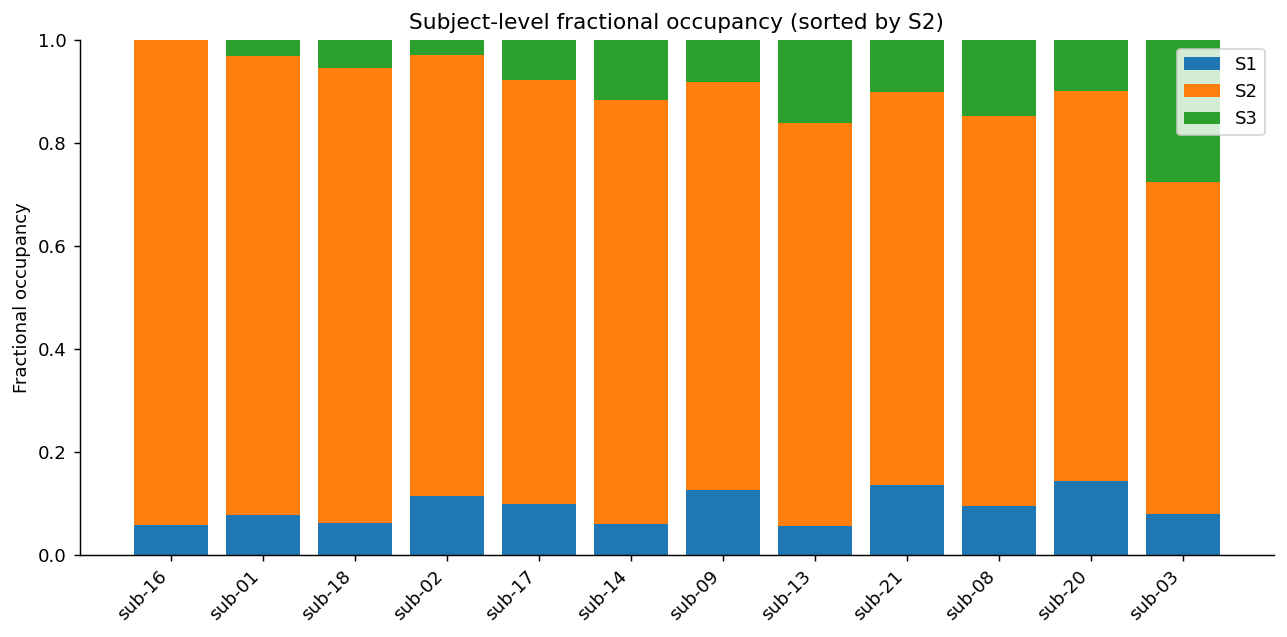

In [16]:
# Subject-level stacked occupancy plot
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = subject_metrics.sort_values('FO_s02', ascending=False).reset_index(drop=True)
x = np.arange(len(plot_df))
ax.bar(x, plot_df['FO_s01'], label='S1')
ax.bar(x, plot_df['FO_s02'], bottom=plot_df['FO_s01'], label='S2')
ax.bar(x, plot_df['FO_s03'], bottom=plot_df['FO_s01'] + plot_df['FO_s02'], label='S3')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['subject'], rotation=45, ha='right')
ax.set_ylabel('Fractional occupancy')
ax.set_title('Subject-level fractional occupancy (sorted by S2)')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / 'subject_fractional_occupancy_stacked.png', bbox_inches='tight')
plt.show()

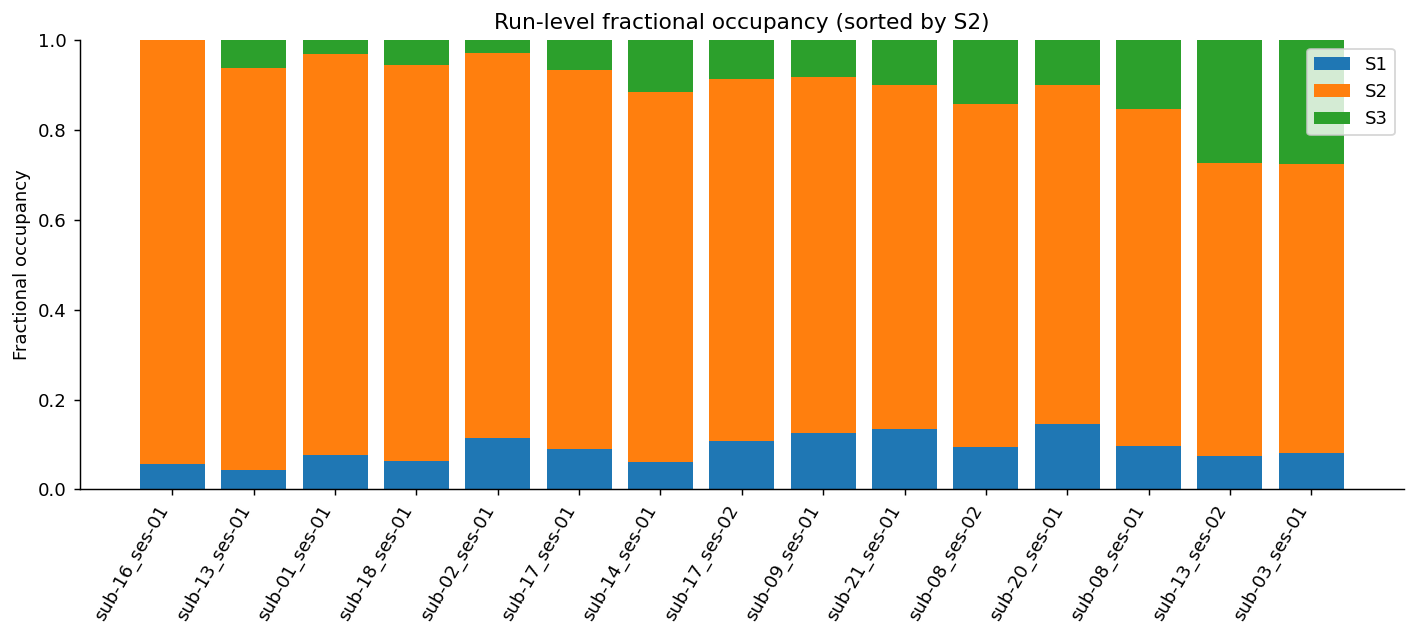

In [17]:
# Run-level occupancy plot
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = run_metrics.sort_values('FO_s02', ascending=False).reset_index(drop=True)
x = np.arange(len(plot_df))
ax.bar(x, plot_df['FO_s01'], label='S1')
ax.bar(x, plot_df['FO_s02'], bottom=plot_df['FO_s01'], label='S2')
ax.bar(x, plot_df['FO_s03'], bottom=plot_df['FO_s01'] + plot_df['FO_s02'], label='S3')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['run'], rotation=60, ha='right')
ax.set_ylabel('Fractional occupancy')
ax.set_title('Run-level fractional occupancy (sorted by S2)')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / 'run_fractional_occupancy_stacked.png', bbox_inches='tight')
plt.show()

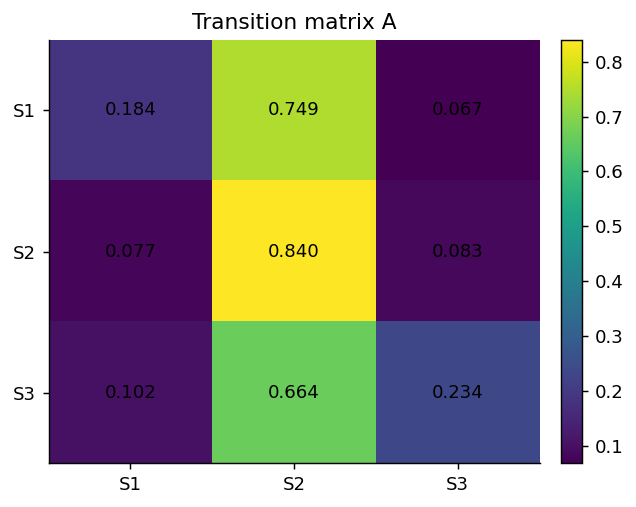

In [18]:
# Transition matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(A, aspect='auto')
ax.set_xticks(np.arange(3))
ax.set_xticklabels(STATE_NAMES)
ax.set_yticks(np.arange(3))
ax.set_yticklabels(STATE_NAMES)
ax.set_title('Transition matrix A')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{A[i, j]:.3f}', ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / 'transition_matrix_A.png', bbox_inches='tight')
plt.show()

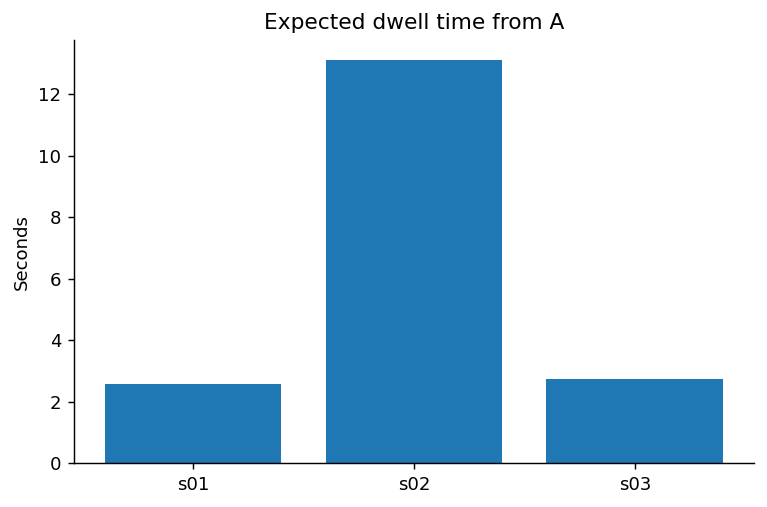

In [19]:
# Dwell times from A
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dwell_from_A['state'], dwell_from_A['dwell_A_sec'])
ax.set_ylabel('Seconds')
ax.set_title('Expected dwell time from A')
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / 'dwell_time_seconds.png', bbox_inches='tight')
plt.show()

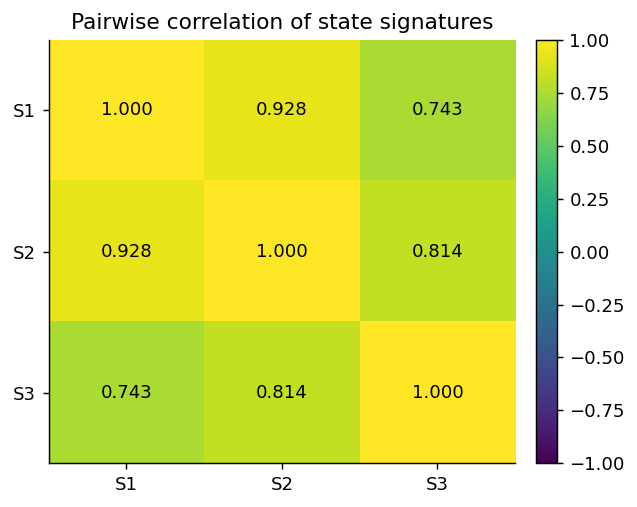

In [20]:
# Signature correlation heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sig_corr, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(np.arange(3))
ax.set_xticklabels(STATE_NAMES)
ax.set_yticks(np.arange(3))
ax.set_yticklabels(STATE_NAMES)
ax.set_title('Pairwise correlation of state signatures')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{sig_corr[i, j]:.3f}', ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUT_FIG_DIR / 'state_signature_correlation.png', bbox_inches='tight')
plt.show()

## 6) One-cell plain-language interpretation

This final cell prints a compact interpretation that you can adapt into Results text.

In [21]:
subj_dom_counts = subject_metrics['dominant_state'].value_counts().sort_index().to_dict()
run_dom_counts = run_metrics['dominant_state'].value_counts().sort_index().to_dict()

msg = f'''
PipelineE K=3 review
--------------------
1. QC passed: {qc['collapsed_run_count']} / {qc['n_runs']} collapsed runs.
2. Final seed = {qc['final_seed']} with FE = {qc['final_seed_fe']:.3f}, FO_max = {qc['final_seed_fo_max']:.3f}, n_active = {qc['final_seed_n_active']}, n_eff = {qc['final_seed_neff']:.3f}.
3. Dominant state across subjects: {subj_dom_counts}
4. Dominant state across runs    : {run_dom_counts}
5. Stationary distribution from A: {np.round(pi, 4)}
6. Expected dwell (TR)           : {np.round(expected_dwell_tr, 3)}
7. Expected dwell (sec, TR=2.1)  : {np.round(expected_dwell_tr * 2.1, 3)}
8. Pairwise signature correlations:
{pd.DataFrame(sig_corr, index=STATE_NAMES, columns=STATE_NAMES).round(3).to_string()}

Interpretation:
- S2 is the dominant state globally.
- S2 is also the dominant state for every subject and every run in these saved outputs.
- S2 is much stickier than S1 and S3.
- S1 and S3 look more like short-lived satellite states that tend to transition into S2.
- If the signature correlations remain high, the states may differ more in persistence / occupancy than in completely different BOLD-correlation topographies.
'''
print(msg)


PipelineE K=3 review
--------------------
1. QC passed: 0 / 15 collapsed runs.
2. Final seed = 23 with FE = 133.245, FO_max = 0.808, n_active = 3, n_eff = 1.864.
3. Dominant state across subjects: {2: 12}
4. Dominant state across runs    : {2: 15}
5. Stationary distribution from A: [0.0888 0.8148 0.0964]
6. Expected dwell (TR)           : [1.225 6.243 1.305]
7. Expected dwell (sec, TR=2.1)  : [ 2.572 13.111  2.741]
8. Pairwise signature correlations:
       S1     S2     S3
S1  1.000  0.928  0.743
S2  0.928  1.000  0.814
S3  0.743  0.814  1.000

Interpretation:
- S2 is the dominant state globally.
- S2 is also the dominant state for every subject and every run in these saved outputs.
- S2 is much stickier than S1 and S3.
- S1 and S3 look more like short-lived satellite states that tend to transition into S2.
- If the signature correlations remain high, the states may differ more in persistence / occupancy than in completely different BOLD-correlation topographies.

